In [4]:
import numpy as np
import pandas as pd
from lib.dataprep import Cleaning, Imputation, RoughFeatureReduction, FeatureSelector, Balancer
from lib.datamodeling import DataModeler
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
import datetime
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

In [5]:
# Load the SECOM dataset
X = pd.read_csv("../data/secom.data", sep=" ", header=None, na_values="NaN")
y = pd.read_csv("../data/secom_labels.data", sep=" ", header=None, names=["label", "timestamp"])

In [6]:
# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y["label"], test_size=0.2, random_state=42, stratify=y["label"])
print("Original:", X.shape, "| Train shape:", X_train.shape, "| Test shape:", X_test.shape)

y_train = y_train.replace({-1: 0})
y_test = y_test.replace({-1: 0})

Original: (1567, 590) | Train shape: (1253, 590) | Test shape: (314, 590)


In [7]:
# This function processes the training data based on the specified parameters:
# outlier handling, missingness threshold, scaling method, KNN imputation, and balancing handling. 
# It returns the processed training data along with the selected features, imputer, and scaler.
def train_data_processing(
        outlier_handling,
        missingness_threshold,
        scaling_method,
        knn_imputation,
        balancing_handling
        # param_grid={}
) -> dict:
    # Data Preprocessing
    X_train_cleaned, _ = Cleaning().flag_missing_values(X_train)
    
    # Outlier handling
    if outlier_handling == 'cap':
        X_train_cleaned = Cleaning().cap_outlier_using_3sigma_rule(X_train_cleaned)
    elif outlier_handling == 'remove':
        X_train_cleaned = Cleaning().mark_outlier_3sigma_as_nan(X_train_cleaned)

    # Rough feature reduction
    X_train_reduced = RoughFeatureReduction().remove_constant_features(X_train_cleaned)
    X_train_reduced = RoughFeatureReduction().remove_features_by_missingness_threshold(X_train_reduced, threshold=missingness_threshold)

    # Impute and Scale missing values
    imputer = Imputation().fit_imputer(X_train_reduced, n_neighbors=knn_imputation['n_neighbors'], weights=knn_imputation['weights'])
    X_train_imputed = Imputation().transform_imputer(X_train_reduced, imputer)
    scaler = Imputation().fit_scaler(X_train_imputed, scaling_method=scaling_method)
    x_train_scaled = Imputation().transform_scaler(X_train_imputed, scaler)


    # Feature selection
    X_train_selected, selected_features = FeatureSelector().boruta_select(x_train_scaled, y_train)
    
    # Feature balancing
    if balancing_handling=='smote':
        X_train_balanced, y_train_balanced = Balancer().apply_smote(X_train_selected, y_train)

    elif balancing_handling=='adasyn':
        X_train_balanced, y_train_balanced = Balancer().apply_adasyn(X_train_selected, y_train)

    elif balancing_handling=='random_oversample':
        X_train_balanced, y_train_balanced = Balancer().apply_random_oversample(X_train_selected, y_train)

    else:
        error_message = f"Invalid balancing handling method: {balancing_handling}. Choose from 'smote', 'adasyn', or 'random_oversample'."
        raise ValueError(error_message)
    
    return X_train_balanced, y_train_balanced, X_train_reduced, selected_features, imputer, scaler

In [8]:
# This function processes the test data based on the selected features, imputer, and scaler from the training data.
def test_data_processing(X_train_reduced, selected_features, imputer, scaler):
    X_test_selected = X_test[X_train_reduced.columns]
    X_test_selected = imputer.transform(X_test_selected)
    X_test_selected = scaler.transform(X_test_selected)
    X_test_selected = pd.DataFrame(X_test_selected, columns=X_train_reduced.columns)
    X_test_selected = X_test_selected[selected_features]

    # print(f"{ts()} Test data processed. Shape: {X_test_selected.shape}")
    return X_test_selected

In [9]:
# This function performs a grid search to find the best hyperparameters for a Random Forest classifier.
def grid_search_rf(X_train_balanced, y_train_balanced):
    param_grid = {
    "n_estimators": [200, 300, 400, 500, 600],
    "max_depth": [None, 5, 10, 15, 20],
    "min_samples_leaf": [1, 3, 5 ,7],
    "class_weight": ["balanced", {0:1, 1:3}, {0:1, 1:5}]
}

    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

    grid = GridSearchCV(
        estimator=RandomForestClassifier(random_state=42, n_jobs=-1),
        param_grid=param_grid,
        scoring="recall",          # focus on detecting faulty wavers
        cv=cv,
        n_jobs=-1,
        verbose=1
    )

    grid.fit(X_train_balanced, y_train_balanced.values.ravel())

    print("Best params:", grid.best_params_)
    # print("Best CV recall:", grid.best_score_)
    best_model = grid.best_estimator_
    return best_model

In [10]:
X_train_balanced, y_train_balanced, X_train_reduced, selected_features, imputer, scaler = train_data_processing(
          outlier_handling='cap'
        , missingness_threshold=0.6
        , scaling_method='robust'
        , knn_imputation={'n_neighbors': 5, 'weights': 'uniform'}
        , balancing_handling='smote')

[2026-07-11 22:50:43] Missing values flagged. Total Missing Values: 33868. DataFrame shape: (1253, 590)
[2026-07-11 22:50:43] Outliers handled. DataFrame shape: (1253, 590)
[2026-07-11 22:50:43] Constant features have been removed. DataFrame shape: (1253, 474)
[2026-07-11 22:50:44] Removed Features with missingness above 60.0%. DataFrame shape: (1253, 450)
[2026-07-11 22:50:45] Missing values imputed. DataFrame shape: (1253, 450)
[2026-07-11 22:50:45] Scaler fitted using robust scaling method. DataFrame shape: (1253, 450)
[2026-07-11 22:51:22] Boruta selected 8 features and marked 1 as tentative. DataFrame shape: (1253, 9)
[2026-07-11 22:51:22] SMOTE applied. Before: {0: 1170, 1: 83}, After: {0: 1170, 1: 1170}. DataFrame shape: (2340, 9)


In [11]:
X_test_selected = test_data_processing(X_train_reduced, selected_features, imputer, scaler)

In [12]:
best_model = grid_search_rf(X_train_balanced, y_train_balanced)

Fitting 5 folds for each of 300 candidates, totalling 1500 fits
Best params: {'class_weight': {0: 1, 1: 5}, 'max_depth': 5, 'min_samples_leaf': 5, 'n_estimators': 200}


Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.57      0.71       293
           1       0.11      0.71      0.18        21

    accuracy                           0.58       314
   macro avg       0.54      0.64      0.45       314
weighted avg       0.91      0.58      0.68       314

Confusion Matrix:
[[166 127]
 [  6  15]]
ROC AUC: 0.684219080123517


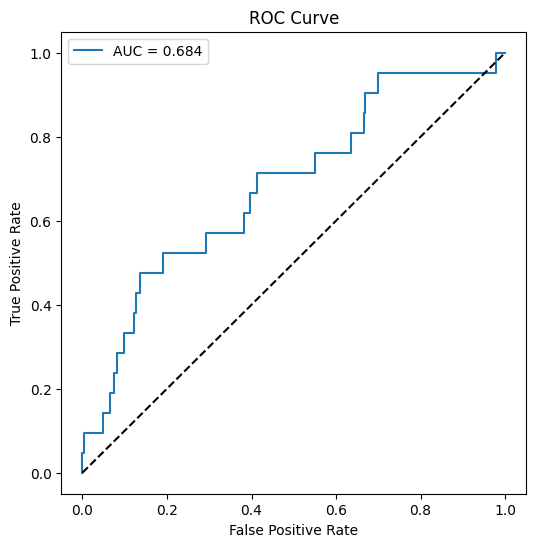

In [13]:
# 1. Predictions
y_pred = best_model.predict(X_test_selected)
y_pred_proba = best_model.predict_proba(X_test_selected)[:, 1]

# 2. Metrics
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc

print("Classification Report:")
print(classification_report(y_test, y_pred))

# 3. Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:")
print(cm)

# 4. ROC Curve + AUC
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
roc_auc = auc(fpr, tpr)
print("ROC AUC:", roc_auc)

# 5. Plot ROC Curve
import matplotlib.pyplot as plt

plt.figure(figsize=(6,6))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
plt.plot([0,1], [0,1], 'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()
